### **Linear SVM-based classification with word embeddings**

This notebook implements a classification approach relying on dense vector representations constructed from static word embeddings (e.g., provided by ItaliaNLP Lab). The document embeddings are generated by aggregating the vectors of individual tokens, testing different aggregation strategies (Mean, Sum and Max Pooling) and Part-Of-Speech (POS) filters -- **Semantic** content words (NOUN, VERB, ADJ, ADV), **Structural**/function words (PRON, ADP, CCONJ, SCONJ, DET, AUX), and **All** words -- to see which linguistic layer is most informative for the task.

Out-of-vocabulary tokens are handled with a normalization fallback chain (exact match -> lowercase -> capitalized -> URL/number/long-token placeholders) so that we lose as few tokens as possible to simple casing or formatting differences.

Model selection is performed by evaluating the trained configurations directly on the Validation set, following the project guidelines. The winning representation is then further refined via a `GridSearchCV` hyperparameter search (5-fold CV on the Training set only, so the Validation set stays untouched for model *selection*), and the resulting model is evaluated on both Validation and Test sets. Visual diagnostics (Confusion Matrix, ROC Curve, Precision-Recall Curve, and Overfitting Analysis) are plotted to comprehensively assess the model's performance.

In [11]:
import os
import ast
import re
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import hinge_loss, f1_score

from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from IPython.display import display


### Data loading and Embeddings extraction

In [12]:
def load_sqlite_embeddings(db_path):
    """
    Connects to the SQLite database and loads the embeddings into a Python dictionary.
    Handles the specific schema where dimensions are stored in separate columns (dim0...dim127).
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Dynamically build the SELECT query for 'key' and 'dim0' through 'dim127'
    dim_cols = [f"dim{i}" for i in range(128)]
    query = f"SELECT key, {', '.join(dim_cols)} FROM store"
    
    cursor.execute(query)
    embeddings = {}
    
    # Fetch all rows and reconstruct the numpy arrays
    for row in cursor.fetchall():
        word = row[0]
        # row[1:129] contains the 128 float values
        vector = np.array(row[1:129], dtype=np.float32) 
        embeddings[word] = vector
        
    conn.close()
    print(f"Loaded {len(embeddings)} word embeddings.")
    return embeddings

# Load the embeddings from the specific database
embeddings_db_path = "../data/embeddings/itwac128.sqlite" 
word_embeddings = load_sqlite_embeddings(embeddings_db_path)

Loaded 1247492 word embeddings.


### Building Document Representations
We define a function to aggregate the word embeddings of a document into a single vector. By zipping the `tokens` and `pos` columns already available in our dataframe, we can easily apply Part-of-Speech filters without reprocessing the text.

In [13]:
# 1. Load the dataframes
print("Loading dataframes...")
df_train = pd.read_pickle("../data/enriched/train_final.pkl")
df_val = pd.read_pickle("../data/enriched/val_final.pkl")
df_test = pd.read_pickle("../data/enriched/test_final.pkl")

# Extract the target vectors
y_train = df_train['label'].copy()
y_val = df_val['label'].copy()
y_test = df_test['label'].copy()

# Maximum length (in characters) beyond which we don't even attempt to parse a string
# as a Python literal: real serialized token/POS lists for a single document are always
# short, so anything longer is certainly plain text, and trying to ast.parse() a very
# long string can blow up the compiler's memory usage before it even fails.
_MAX_LITERAL_LEN = 5000

def _maybe_parse_list(s):
    """
    Safely turns a possibly-serialized string into a list of strings.
    Only attempts ast.literal_eval() when the string clearly *looks* like a
    list literal (starts with '[' and ends with ']') and is short enough to
    be a plausible per-document list -- never on arbitrary/long free text.
    Falls back to a plain whitespace split in every other case, and never
    lets a parsing failure (of any kind, including MemoryError) propagate.
    """
    s_stripped = s.strip()
    looks_like_list = s_stripped.startswith('[') and s_stripped.endswith(']')
    if looks_like_list and len(s_stripped) <= _MAX_LITERAL_LEN:
        try:
            parsed = ast.literal_eval(s_stripped)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
    return s.split()


def normalize_and_get_vector(word, embeddings_dict):
    """
    Looks up a token in the embeddings dictionary, falling back through a
    chain of normalization strategies before giving up. This recovers a lot
    of tokens that would otherwise be treated as out-of-vocabulary purely
    because of casing, URLs, numbers, or anomalously long strings.
    """
    # 1. Direct match (fastest, most common case)
    if word in embeddings_dict:
        return embeddings_dict[word]

    # 2. Lowercase match
    word_lower = word.lower()
    if word_lower in embeddings_dict:
        return embeddings_dict[word_lower]

    # 3. Capitalized match (useful for names at the start of a sentence)
    word_cap = word.capitalize()
    if word_cap in embeddings_dict:
        return embeddings_dict[word_cap]

    # 4. URL normalization
    if re.match(r'(https?://|www\.)\S+', word):
        return embeddings_dict.get("___URL___")

    # 5. Very long tokens (likely noise/typos/concatenations)
    if len(word) > 26:
        return embeddings_dict.get("__LONG-LONG__")

    # 6. Numbers: any token containing a digit maps to a generic placeholder
    if any(ch.isdigit() for ch in word):
        return embeddings_dict.get("@Dg")

    return None


def get_doc_embedding(tokens, pos_tags, embeddings_dict, pos_filters=None, agg_method='mean'):
    """Converts a document into a dense vector by aggregating its word embeddings."""

    # Safety check in case tokens/pos were serialized as strings instead of lists
    if isinstance(tokens, str):
        tokens = _maybe_parse_list(tokens)
    if isinstance(pos_tags, str):
        pos_tags = _maybe_parse_list(pos_tags)

    vecs = []
    for t, p in zip(tokens, pos_tags):
        # Apply POS filtering if specified
        if pos_filters is not None and p not in pos_filters:
            continue

        vec = normalize_and_get_vector(t, embeddings_dict)
        if vec is not None:
            vecs.append(vec)

    # Handle empty documents (e.g., all words filtered out or out-of-vocabulary)
    if len(vecs) == 0:
        dim = len(next(iter(embeddings_dict.values()))) if embeddings_dict else 128
        return np.zeros(dim, dtype=np.float32)

    # Aggregate embeddings
    stacked = np.vstack(vecs)
    if agg_method == 'mean':
        return np.mean(stacked, axis=0)
    elif agg_method == 'sum':
        return np.sum(stacked, axis=0)
    elif agg_method == 'max':
        return np.max(stacked, axis=0)
    else:
        raise ValueError("Unsupported aggregation method. Use 'mean', 'sum' or 'max'.")


def create_feature_matrix(df, embeddings_dict, pos_filters, agg_method):
    """
    Applies the document embedding strategy to the entire DataFrame.
    Dynamically checks for the correct column names (e.g., 'tokens' vs 'tokens_processed').
    """
    tok_col = 'tokens_processed' if 'tokens_processed' in df.columns else 'tokens'
    pos_col = 'pos_processed' if 'pos_processed' in df.columns else 'pos'

    if tok_col not in df.columns and 'lemmas_processed' in df.columns:
        tok_col = 'lemmas_processed'

    features = df.apply(
        lambda row: get_doc_embedding(row[tok_col], row[pos_col], embeddings_dict, pos_filters, agg_method),
        axis=1
    )
    return np.vstack(features.values)


Loading dataframes...


### Model selection via Validation Set

Following the project guidelines, different text representations are tested by varying the aggregation method (Mean / Sum / Max) and the POS categories considered:

* **Semantic** (`NOUN`, `VERB`, `ADJ`, `ADV`) -- the topical/content words of the text.
* **Structural** (`PRON`, `ADP`, `CCONJ`, `SCONJ`, `DET`, `AUX`) -- function words, capturing stylometric/syntactic patterns rather than content.
* **All** words -- no POS filtering, keeping the full context.

3 pooling strategies x 3 POS configurations = 9 configurations, each evaluated on the Validation Set to select the best-performing representation.

In [14]:
# Define the experimental configurations: 3 pooling strategies x 3 POS filters
pos_configs = {
    "All": None,
    "Semantic": ['NOUN', 'VERB', 'ADJ', 'ADV'],
    "Structural": ['PRON', 'ADP', 'CCONJ', 'SCONJ', 'DET', 'AUX'],
}
pooling_strategies = ['mean', 'sum', 'max']

configs = {
    f"{pos_name}_{pool}": {"pos": pos_filter, "agg": pool}
    for pool in pooling_strategies
    for pos_name, pos_filter in pos_configs.items()
}

val_results = []
best_score = 0
best_config_name = None
best_params = None

print("--- Starting Validation Phase ---")

for config_name, params in configs.items():
    print(f"Testing Configuration: {config_name}")

    # 1. Create dense feature matrices
    X_train_dense = create_feature_matrix(df_train, word_embeddings, params["pos"], params["agg"])
    X_val_dense = create_feature_matrix(df_val, word_embeddings, params["pos"], params["agg"])

    # 2. Build the pipeline (Scaling is highly recommended for dense embeddings)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=1.0, random_state=42, dual=False, max_iter=5000))
    ])

    # 3. Fit on Training set
    pipeline.fit(X_train_dense, y_train)

    # 4. Predict and evaluate on Validation set
    pred_val = pipeline.predict(X_val_dense)
    mean_score = f1_score(y_val, pred_val, average="macro")

    print(f"Validation Macro-F1: {mean_score:.4f}\n")
    val_results.append({"Configuration": config_name, "Macro F1 (Val)": mean_score})

    # Track the best configuration
    if mean_score > best_score:
        best_score = mean_score
        best_config_name = config_name
        best_params = params

# Leaderboard, sorted by Macro F1
val_results_df = pd.DataFrame(val_results).sort_values(by="Macro F1 (Val)", ascending=False).reset_index(drop=True)
print("\n--- VALIDATION LEADERBOARD ---")
display(val_results_df)

print(f"\n*** Best Configuration Found: {best_config_name} (Val Macro-F1: {best_score:.4f}) ***\n")


--- Starting Validation Phase ---
Testing Configuration: All_mean
Validation Macro-F1: 0.9485

Testing Configuration: Semantic_mean
Validation Macro-F1: 0.9100

Testing Configuration: Structural_mean
Validation Macro-F1: 0.9095

Testing Configuration: All_sum
Validation Macro-F1: 0.9615

Testing Configuration: Semantic_sum
Validation Macro-F1: 0.9299

Testing Configuration: Structural_sum
Validation Macro-F1: 0.9280

Testing Configuration: All_max
Validation Macro-F1: 0.8980

Testing Configuration: Semantic_max
Validation Macro-F1: 0.8655

Testing Configuration: Structural_max
Validation Macro-F1: 0.8084


--- VALIDATION LEADERBOARD ---


,Configuration,Macro F1 (Val)
0,All_sum,0.961493
1,All_mean,0.948499
2,Semantic_sum,0.929928
3,Structural_sum,0.927977
4,Semantic_mean,0.909982
5,Structural_mean,0.909496
6,All_max,0.898000
7,Semantic_max,0.865496
8,Structural_max,0.808448



*** Best Configuration Found: All_sum (Val Macro-F1: 0.9615) ***



### Hyperparameter Tuning of the Winning Configuration

Before the final test evaluation, we run a `GridSearchCV` (5-fold CV, scored on Macro-F1) over `LinearSVC`'s regularization strength `C`, penalty and loss, using **only the Training set** -- the Validation set is left untouched here since it was already used to pick the representation above, and must stay unseen until the final evaluation.

We explicitly pair each `penalty`/`loss` combination with the only `dual` setting `LinearSVC` supports for it (`hinge` loss requires `dual=True`; `l1` penalty requires `dual=False`), and raise `max_iter` to avoid convergence warnings given the relatively small (128-dim) feature space.

In [15]:
# Rebuild the feature matrices for the winning configuration only
print(f"Rebuilding features with best configuration: {best_config_name} -> {best_params}")

X_train_best = create_feature_matrix(df_train, word_embeddings, best_params["pos"], best_params["agg"])
X_val_best   = create_feature_matrix(df_val,   word_embeddings, best_params["pos"], best_params["agg"])
X_test_best  = create_feature_matrix(df_test,  word_embeddings, best_params["pos"], best_params["agg"])

pipeline_tune = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(random_state=42, max_iter=20000))
])

# Each dict pairs penalty/loss with the only valid `dual` setting, to avoid
# both invalid combinations and unnecessary ConvergenceWarnings.
param_grid = [
    {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100], "clf__penalty": ["l2"], "clf__loss": ["hinge"], "clf__dual": [True]},
    {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100], "clf__penalty": ["l2"], "clf__loss": ["squared_hinge"], "clf__dual": [False]},
    {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100], "clf__penalty": ["l1"], "clf__loss": ["squared_hinge"], "clf__dual": [False]},
]

grid_search = GridSearchCV(
    pipeline_tune,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_best, y_train)

print(f"\nBest hyperparameters: {grid_search.best_params_}")
print(f"Best CV Macro-F1 (Training set, 5-fold): {grid_search.best_score_:.4f}")

final_pipeline = grid_search.best_estimator_


Rebuilding features with best configuration: All_sum -> {'pos': None, 'agg': 'sum'}
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best hyperparameters: {'clf__C': 1, 'clf__dual': False, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l2'}
Best CV Macro-F1 (Training set, 5-fold): 0.9652


### Final Evaluation on Validation and Test Sets

Using the tuned pipeline from the grid search above (already fit on the Training set), we predict on the Validation and Test sets and report the full classification metrics for both.

In [16]:
# Predicted labels on each split, using the tuned pipeline
pred_train = final_pipeline.predict(X_train_best)
pred_val   = final_pipeline.predict(X_val_best)
pred_test  = final_pipeline.predict(X_test_best)

# Decision function scores (LinearSVC has no predict_proba -> needed for ROC/PR curves and hinge loss)
scores_train = final_pipeline.decision_function(X_train_best)
scores_val   = final_pipeline.decision_function(X_val_best)
scores_test  = final_pipeline.decision_function(X_test_best)

classes = sorted(y_train.unique())
n_classes = len(classes)

print("=== Classification Report - Validation Set ===")
print(classification_report(y_val, pred_val, digits=4))

print("=== Classification Report - Test Set ===")
print(classification_report(y_test, pred_test, digits=4))


=== Classification Report - Validation Set ===
              precision    recall  f1-score   support

           0     0.9743    0.9480    0.9610      1000
           1     0.9494    0.9750    0.9620      1000

    accuracy                         0.9615      2000
   macro avg     0.9618    0.9615    0.9615      2000
weighted avg     0.9618    0.9615    0.9615      2000

=== Classification Report - Test Set ===
              precision    recall  f1-score   support

           0     0.8894    0.9330    0.9107      1000
           1     0.9295    0.8840    0.9062      1000

    accuracy                         0.9085      2000
   macro avg     0.9095    0.9085    0.9084      2000
weighted avg     0.9095    0.9085    0.9084      2000



### Visual Diagnostics

We now inspect the final model's behaviour with the standard set of diagnostic plots: confusion matrices (Validation vs Test), ROC curve, Precision-Recall curve, and an overfitting analysis comparing performance across the three splits.

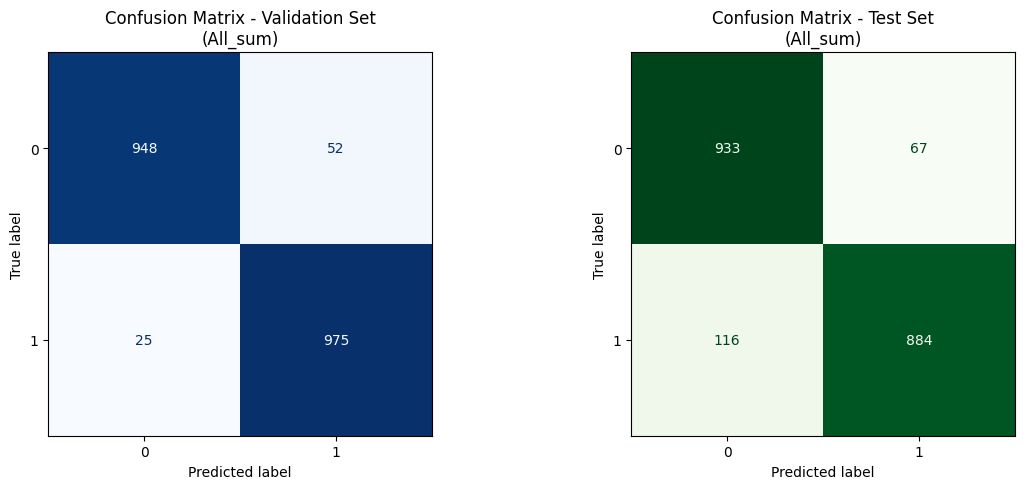

In [17]:
# Confusion matrices: Validation vs Test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_val, pred_val, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix - Validation Set\n({best_config_name})")

ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Confusion Matrix - Test Set\n({best_config_name})")

plt.tight_layout()
plt.show()


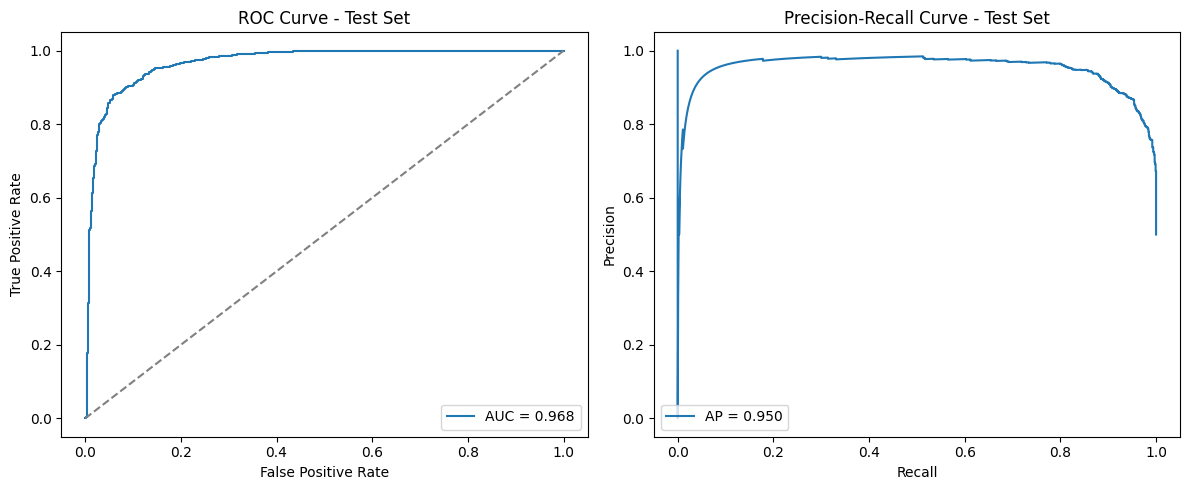

In [18]:
# ROC Curve and Precision-Recall Curve on the Test Set
# Handles both the binary case and the multiclass case (One-vs-Rest) automatically,
# depending on how many distinct labels the task actually has.
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, scores_test)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve - Test Set")
    axes[0].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_test, scores_test)
    ap = average_precision_score(y_test, scores_test)
    axes[1].plot(recall, precision, label=f"AP = {ap:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve - Test Set")
    axes[1].legend(loc="lower left")
else:
    y_test_bin = label_binarize(y_test, classes=classes)
    for i, c in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], scores_test[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, label=f"Class {c} (AUC={roc_auc:.3f})")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve (One-vs-Rest) - Test Set")
    axes[0].legend(loc="lower right", fontsize=8)

    for i, c in enumerate(classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], scores_test[:, i])
        ap = average_precision_score(y_test_bin[:, i], scores_test[:, i])
        axes[1].plot(recall, precision, label=f"Class {c} (AP={ap:.3f})")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve (One-vs-Rest) - Test Set")
    axes[1].legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()


### Overfitting Analysis

We compare Macro-F1 and hinge loss across Training, Validation and Test to check how much performance degrades from seen to unseen data — a large Train/Test gap is a sign of overfitting.

Macro-F1  -> Train: 0.9785 | Val: 0.9615 | Test: 0.9084
HingeLoss -> Train: 0.0735 | Val: 0.1105 | Test: 0.3820


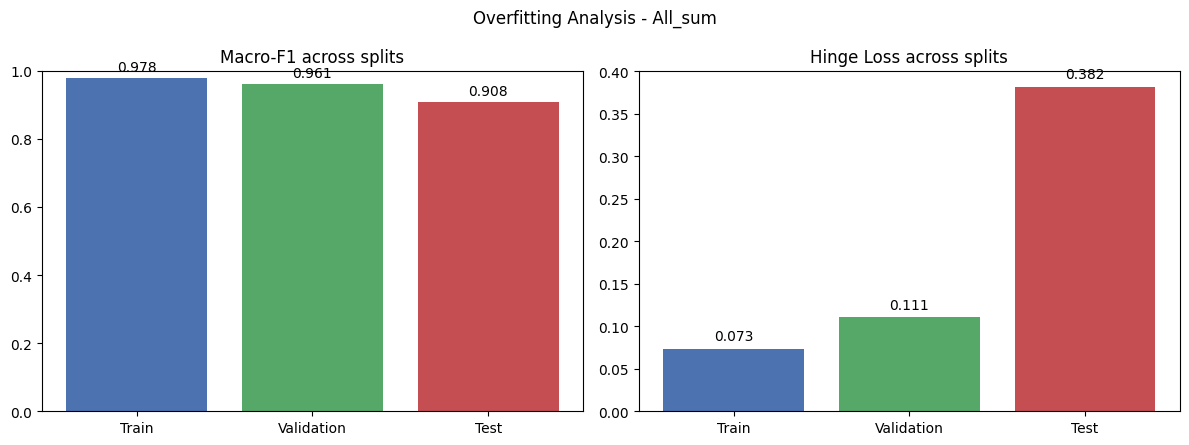


Generalization gap (Train - Test Macro-F1): 0.0701
=> The gap is limited: the model generalizes reasonably well to unseen data.


In [20]:
# Overfitting analysis: Macro-F1 and Hinge Loss across Train / Validation / Test
def compute_hinge(y_true, scores):
    return hinge_loss(y_true, scores) if n_classes == 2 else hinge_loss(y_true, scores, labels=classes)

f1_train = f1_score(y_train, pred_train, average="macro")
f1_val   = f1_score(y_val,   pred_val,   average="macro")
f1_test  = f1_score(y_test,  pred_test,  average="macro")

hinge_train = compute_hinge(y_train, scores_train)
hinge_val   = compute_hinge(y_val,   scores_val)
hinge_test  = compute_hinge(y_test,  scores_test)

print(f"Macro-F1  -> Train: {f1_train:.4f} | Val: {f1_val:.4f} | Test: {f1_test:.4f}")
print(f"HingeLoss -> Train: {hinge_train:.4f} | Val: {hinge_val:.4f} | Test: {hinge_test:.4f}")

sets = ["Train", "Validation", "Test"]
f1_scores = [f1_train, f1_val, f1_test]
hinge_scores = [hinge_train, hinge_val, hinge_test]
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(sets, f1_scores, color=colors)
axes[0].set_ylim(0, 1)
axes[0].set_title("Macro-F1 across splits")
for i, v in enumerate(f1_scores):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

axes[1].bar(sets, hinge_scores, color=colors)
axes[1].set_title("Hinge Loss across splits")
for i, v in enumerate(hinge_scores):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.suptitle(f"Overfitting Analysis - {best_config_name}")
plt.tight_layout()
plt.show()

gap = f1_train - f1_test
print(f"\nGeneralization gap (Train - Test Macro-F1): {gap:.4f}")
if gap > 0.10:
    print("=> Significant gap detected: the model may be overfitting the training data.")
else:
    print("=> The gap is limited: the model generalizes reasonably well to unseen data.")
